In [1]:
import numpy as np
import torch
import torch.nn as nn

import matplotlib.pyplot as plt

In [2]:
hbar = 1.054571817 * 10**(-34)

def comutator(A, B):
    return A@B-B@A
def anticomutator(A, B):
    return A@B+B@A
def lindbladOp(L, rho):
    return L @ rho @ np.conj(L.T) - 0.5*anticomutator(np.conj(L.T)@L,rho)
def FixRho(rho):
    # 1. Wymuszenie hermitowskości
    rho = (rho + rho.conj().T) / 2

    # 2. Diagonalizacja
    eigvals, eigvecs = np.linalg.eigh(rho)

    # 3. Naprawa wartości własnych (ujemne → 0)
    eigvals = np.clip(eigvals, 0, None)

    # 4. Rekonstrukcja macierzy
    rho_fixed = eigvecs @ np.diag(eigvals) @ eigvecs.conj().T

    # 5. Normalizacja śladu do 1
    rho_fixed /= np.trace(rho_fixed)

    return rho_fixed
def EvoOp(H, L_list, rho):
    op = -1j/hbar*comutator(H, rho)
    for Li in L_list:
        op += lindbladOp(Li,rho)
    return op

def plot_signals(signals, t_axis = None, labels=None, points=None, pointlabels=None):
    fig, ax = plt.subplots()
    for s, sig in enumerate(signals):
        if t_axis is None:
            t_axis = np.linspace(0.,1., num=len(sig), endpoint=True)
        ax.plot(t_axis, sig, label=labels[s])
    if points is not None:
        for p, pts in enumerate(points):
            ax.scatter(pts[0], pts[1], marker='x', label=pointlabels[p])
    if labels is not None or pointlabels is not None: ax.legend()
    plt.show()

In [3]:
class Lindblad_solver:

    def __init__(self, t1, t2, dt):
        self.dt = dt
        self.t1 = t1
        self.t2 = t2

        g1 = 1/t1
        g2 = 1/t2

        L1 = np.array([
            [0,  1],
            [0, 0]
        ], dtype=complex)*np.sqrt(g1)

        L2 = np.array([
            [1,  0],
            [0, -1]
        ], dtype=complex)*np.sqrt(g2)

        self.H = np.array([
            [0,  0],
            [0, 0]
        ], dtype=complex)

        self.L_list = [L1, L2]

    def run_simulation(self, rho0, time=10**(-11)):
        states = [rho0.copy()]
        times = [0]
        rho_curr = rho0
        
        no_steps = int(time/self.dt)
        
        # iterate subseqent time-steps
        for _ in range(no_steps):
            k1 = EvoOp(self.H, self.L_list, rho_curr)
            k2 = EvoOp(self.H, self.L_list, rho_curr + dt/2 * k1)
            k3 = EvoOp(self.H, self.L_list, rho_curr + dt/2 * k2)
            k4 = EvoOp(self.H, self.L_list, rho_curr + dt * k3)

            rho_next = rho_curr + dt/6 * (k1 + 2*k2 + 2*k3 + k4)

            rho_next = FixRho(rho_next)

            rho_curr = rho_next
            times.append((_ + 1) * dt)
            states.append(rho_curr.copy())

        return [np.array(times), np.array(states)]

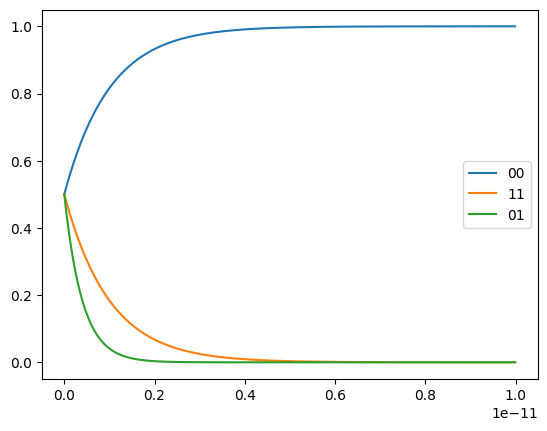

In [4]:
# let's start with numerical solution
dt = 1 * 10**(-14) #0.01ps
solver = Lindblad_solver(1 * 10**(-12), 1 * 10**(-12), dt)

psi0 = np.array([1, 1], dtype=complex)
psi0 /= np.linalg.norm(psi0)

rho0 = np.outer(psi0, np.conj(psi0))

[times, states] = solver.run_simulation(rho0)
#print(times)

plot_signals([np.abs(states[:, 0, 0]), np.abs(states[:, 1, 1]), np.abs(states[:, 0, 1])],
                  labels = ['00', '11', '01'],
                  t_axis = times)

In [9]:
# define NN estimator
def build_mlp(layer_sizes=[1,256,128,64,32,1], regularization=None, activation='tanh', output='linear', dropout_rate=0.2):

    layers = []
    for i in range(len(layer_sizes) - 2):
        linear_layer = nn.Linear(layer_sizes[i], layer_sizes[i+1])

        # assign most suitable initialization for activation functions
        if activation == 'relu':
            nn.init.kaiming_normal_(linear_layer.weight,
                                    mode='fan_in', nonlinearity='relu')
        elif activation == 'tanh':
            nn.init.xavier_uniform_(linear_layer.weight)
        else:
            nn.init.kaiming_normal_(linear_layer.weight,
                                    mode='fan_in', nonlinearity='leaky_relu')
        # Add the initialized linear layer to the model
        layers.append(linear_layer)

        if regularization == 'batch_normalization':
            layers.append(nn.BatchNorm1d(layer_sizes[i+1]))
        elif regularization == 'dropout':
            layers.append(nn.Dropout(p=dropout_rate))

        if activation == 'relu':
            layers.append(nn.ReLU())
        elif activation == 'tanh':
            layers.append(nn.Tanh())
        else:
            layers.append(nn.LeakyReLU())

    linear_layer = nn.Linear(layer_sizes[-2], layer_sizes[-1])
    nn.init.xavier_uniform_(linear_layer.weight)
    layers.append(linear_layer)
    if output == 'lrelu':
        layers.append(nn.LeakyReLU())
    elif output == 'tanh':
        layers.append(nn.Tanh())
    #layers.append(nn.Softmax(dim=1))
    model = nn.Sequential(*layers)
    return model


class NN_solver:

    def __init__(self, predictor, solver, data, collocation_points):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.predictor = predictor.to(self.device)
        self.solver = solver
        self.data_points = torch.from_numpy(data[0]).to(torch.float32).view(-1,1).to(self.device)
        self.data_values = torch.from_numpy(data[1]).to(torch.float32).view(-1,1).to(self.device)
        self.collocation_points = torch.from_numpy(collocation_points).to(torch.float32).view(-1,1).requires_grad_(True).to(self.device)

    def ip_nn(self, t):
        im1 = self.predictor(t-self.solver.dt) #self.solver.dt)#torch.tensor(self.solver.dt))
        i0 = self.predictor(t)
        return self.solver.f(im1, i0)

    def f_nn(self, t):
        # compare prediction obrained using ip_nn and direct nn prediction for t+1
        t = t * self.solver.dt
        ip = self.ip_nn(t)
        return self.predictor(t+self.solver.dt) - ip

    def f_nn0(self, t):
        #dt = self.solver.dt
        dt = 0.01
        t = t * self.solver.dt
        tp = t+dt
        tm = t-dt
        i = self.predictor(t)
        ip = self.predictor(tp)
        im = self.predictor(tm)
        didt = (ip - im)/dt/2.
        di2dt2 = (ip - i*2. + im)/dt/dt
        return di2dt2+didt*.1+i
        #return di2dt2 + didt*self.solver.R/self.L(i, *self.solver.params) + i/self.solver.C/self.L(i, *self.solver.params)

    def f_nn1(self, t):
        dt = 0.01
        t = t * dt
        i = self.predictor(t)
        didt = self.grad(i, t)[0]
        di2dt2 = self.grad(didt, t)[0]
        return di2dt2+didt*.1+i

    def grad(self, outputs, inputs):
        """Computes the partial derivative of
        an output with respect to an input."""
        return torch.autograd.grad(
            outputs,
            inputs,
            grad_outputs=torch.ones_like(outputs),
            create_graph=True
        )

    def make_predictions(self, t):
        t = torch.from_numpy(t).to(torch.float32).view(-1,1).to(self.device)
        self.predictor.eval()
        with torch.no_grad():
            return self.predictor(t).cpu().numpy()


class Training:

    def __init__(self, nn_solver, no_epochs, lr, physics_loss=True):
        self.nn_solver = nn_solver
        self.no_epochs = no_epochs
        self.datalossF = nn.MSELoss()
        self.physics_loss = physics_loss
        self.optimizer = torch.optim.Adam(self.nn_solver.predictor.parameters(), lr=lr)

    def training_loop(self):

        store_loss = []
        for epoch in range(self.no_epochs):
            self.nn_solver.predictor.train()
            self.optimizer.zero_grad()
            physicsL = self.nn_solver.f_nn0(self.nn_solver.collocation_points).square().sum()
            dataL = self.datalossF(self.nn_solver.predictor(self.nn_solver.data_points*self.nn_solver.solver.dt),
                                   self.nn_solver.data_values)
            loss = dataL*len(self.nn_solver.collocation_points)
            if self.physics_loss:
                loss += physicsL
            loss.backward()
            self.optimizer.step()
            store_loss.append(loss.item())

            if epoch % 1000 == 0:
                print(f"Epoch [{epoch}/{self.no_epochs}], Data Loss: {dataL:.5f}, Physics Loss: {physicsL:.5f}")

        #self.plot_prediction()
        plt.plot(store_loss[500:])
        plt.yscale('log')
        plt.title('Loss')
        plt.show()

In [21]:
# now define PINN solver
data_indices = np.array([0,10,50])
data_times = times[data_indices]
data_values = states[data_indices]
no_collocation_points = 100
collocation_points_times = np.sort(np.random.uniform(np.min(times), np.max(times), no_collocation_points))


solver_nn = NN_solver(predictor=build_mlp(),
                               solver=solver,
                               data=[data_points, data_values],
                               collocation_points=collocation_points_times)

# train NN predictor
train_nn = Training(solver_nn, no_epochs=20000, lr=1.e-3, physics_loss=True)
train_nn.training_loop()

0.0


RuntimeError: The size of tensor a (10) must match the size of tensor b (12) at non-singleton dimension 0

In [ ]:
pred_PINN = solver_nn.make_predictions(np.linspace(0.,no_timesteps*dt, num=no_timesteps+2, endpoint=True))
plot_signals([it, pred_PINN],
             labels = ['numerics', 'PINN'],
             t_axis = np.linspace(0.,no_timesteps*dt, num=no_timesteps+2, endpoint=True),
             points = [[data_points*dt, data_values], [collocation_points*dt, np.zeros(len(collocation_points))]],
             pointlabels = ['data points', 'collocation points'])